# Explore here

Cargando datos...
Datos cargados!
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Columnas disponibles:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Datos filtrados (solo las columnas que necesitamos):
   Latitude  Longitude  MedInc
0     37.88    -122.23  8.3252
1     37.86    -122.22  8.3014
2     37.85    -122.24  7.2574
3     37.85    -122.25  5.

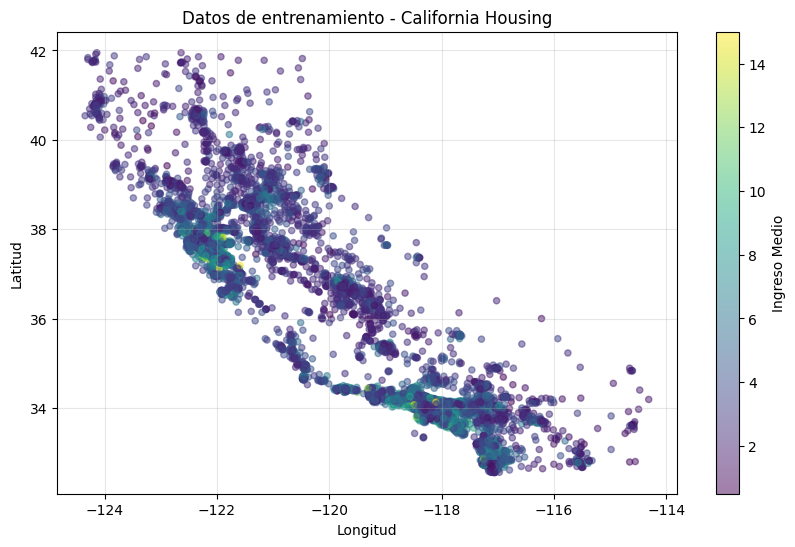


✅ Paso 1 completado!


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Cargar el dataset
print("Cargando datos...")
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv'
datos = pd.read_csv(url)

print("Datos cargados!")
print(datos.head())

# Ver todas las columnas que tenemos
print("\nColumnas disponibles:")
print(datos.columns.tolist())

# Seleccionar solo las columnas que necesitamos
datos_filtrados = datos[['Latitude', 'Longitude', 'MedInc']].copy()

print("\nDatos filtrados (solo las columnas que necesitamos):")
print(datos_filtrados.head(10))

# Ver si hay valores nulos
print("\nValores nulos:")
print(datos_filtrados.isnull().sum())

# Ver un resumen de los datos
print("\nEstadísticas básicas:")
print(datos_filtrados.describe())

# Dividir en train y test
print("\n--- Dividiendo en train y test ---")
X_train, X_test = train_test_split(datos_filtrados, test_size=0.2, random_state=42)

print(f"Tamaño del train: {len(X_train)}")
print(f"Tamaño del test: {len(X_test)}")

# Graficar los datos de entrenamiento para ver cómo se ven
plt.figure(figsize=(10, 6))
plt.scatter(X_train['Longitude'], X_train['Latitude'], alpha=0.5, s=20, c=X_train['MedInc'], cmap='viridis')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Datos de entrenamiento - California Housing')
plt.colorbar(label='Ingreso Medio')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✅ Paso 1 completado!")

Entrenando K-Means...
Listo!
[1 1 3 1 5 0 1 0 1 1 0 1 5 0 1 1 0 4 1 1]
       Latitude  Longitude  MedInc cluster
14196     32.71    -117.03  3.2596       1
8267      33.77    -118.16  3.8125       1
17445     34.66    -120.48  4.1563       3
14265     32.69    -117.11  1.9425       1
2271      36.78    -119.80  3.5542       5
cluster
1    8465
0    3921
4    1764
3     913
5     897
2     552
Name: count, dtype: int64


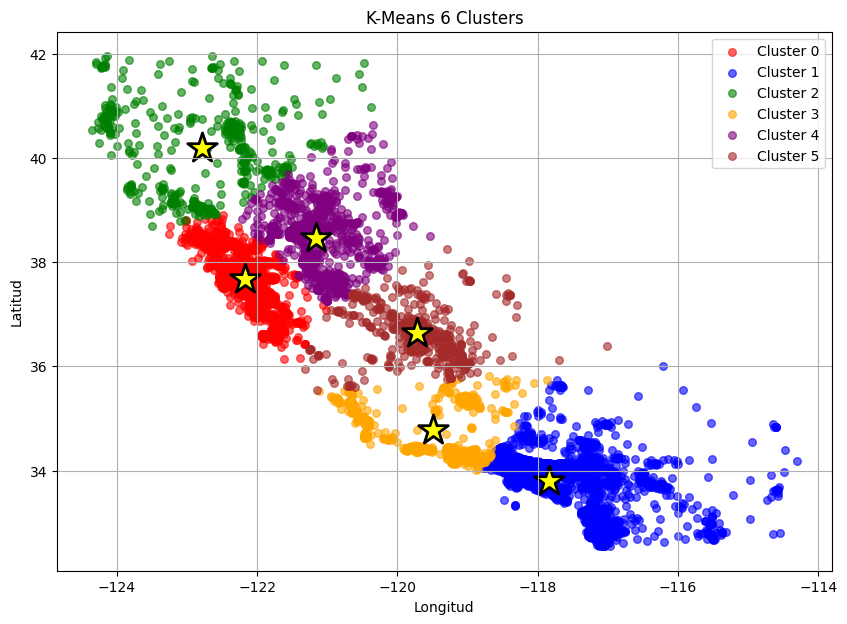

Clusters creados!


In [3]:
# Paso 2

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Entrenar K-Means
print("Entrenando K-Means...")

# Preparar datos - solo Latitude y Longitude
X = X_train[['Latitude', 'Longitude']].values

# Crear K-Means con 6 clusters
km = KMeans(n_clusters=6, random_state=42)
km.fit(X)

# Predecir los clusters
pred = km.predict(X)

print("Listo!")
print(pred[:20])

# Añadir el cluster al dataframe
X_train['cluster'] = pred

# Convertir a category (como dijeron en clase)
X_train['cluster'] = X_train['cluster'].astype('category')

print(X_train.head())

# Ver cuántos en cada cluster
print(X_train['cluster'].value_counts())

# Graficar
plt.figure(figsize=(10, 7))

colores = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i in range(6):
    datos_cluster = X_train[X_train['cluster'] == i]
    plt.scatter(datos_cluster['Longitude'], datos_cluster['Latitude'], 
                c=colores[i], label=f'Cluster {i}', alpha=0.6, s=30)

# Graficar centros
plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 0], 
            marker='*', s=500, c='yellow', edgecolors='black', linewidth=2)

plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('K-Means 6 Clusters')
plt.legend()
plt.grid()
plt.show()

print("Clusters creados!")


Haciendo predicciones en el conjunto test...
Predicciones hechas!
[5 3 0 3 0 1 1 1 0 1 4 1 1 3 1 1 0 4 1 4]

Datos test con clusters:
       Latitude  Longitude  MedInc cluster
20046     36.06    -119.01  1.6812       5
3024      35.14    -119.46  2.5313       3
15663     37.80    -122.44  3.4801       0
20484     34.28    -118.72  5.7376       3
9814      36.62    -121.93  3.7250       0


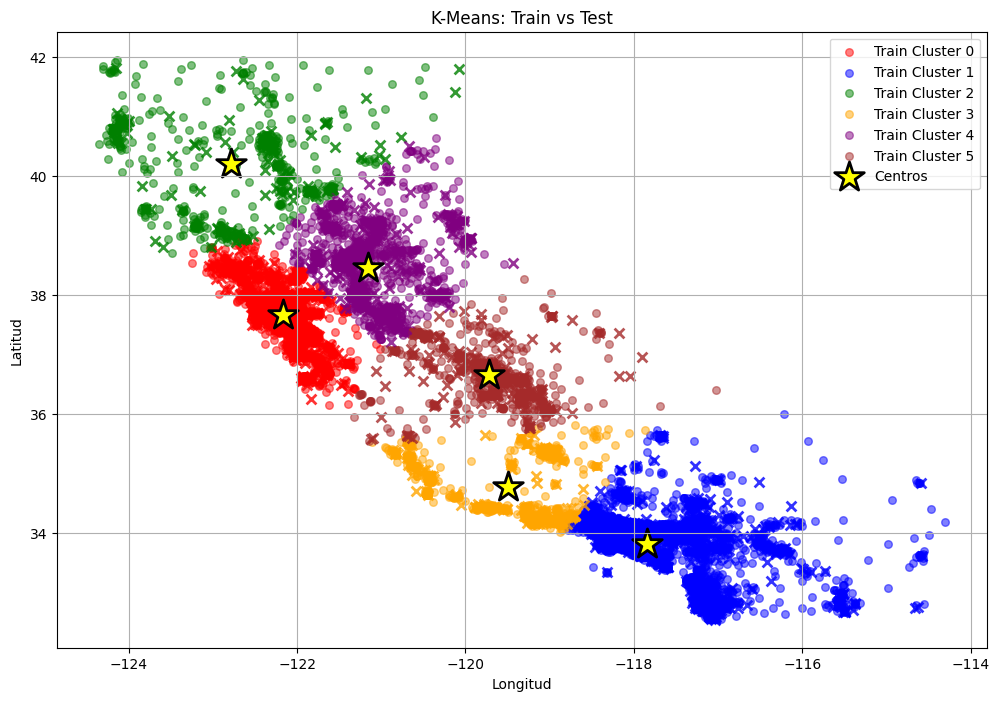


✅ Paso 3 completado!

Observaciones:
- Los puntos test (con X) se distribuyen similar a los train
- El modelo parece predecir bien los nuevos datos
- Los clusters están bien separados geográficamente


In [ ]:
# Paso 3:  Usar el modelo entrenado para predecir en test
print("Haciendo predicciones en el conjunto test...")

# Preparar datos test igual que train
X_test_datos = X_test[['Latitude', 'Longitude']].values

# Predecir con el modelo ya entrenado
pred_test = km.predict(X_test_datos)

print("Predicciones hechas!")
print(pred_test[:20])

# Añadir los clusters al X_test también
X_test['cluster'] = pred_test
X_test['cluster'] = X_test['cluster'].astype('category')

print("\nDatos test con clusters:")
print(X_test.head())

# Graficar train y test juntos para ver si están bien
plt.figure(figsize=(12, 8))

colores = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

# Graficar train (puntos normales)
for i in range(6):
    datos_train = X_train[X_train['cluster'] == i]
    plt.scatter(datos_train['Longitude'], datos_train['Latitude'], 
                c=colores[i], label=f'Train Cluster {i}', alpha=0.5, s=30)

# Graficar test (con un marcador diferente)
for i in range(6):
    datos_test = X_test[X_test['cluster'] == i]
    plt.scatter(datos_test['Longitude'], datos_test['Latitude'], 
                c=colores[i], marker='x', s=50, alpha=0.8, linewidth=2)

# Centros
plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 0], 
            marker='*', s=500, c='yellow', edgecolors='black', linewidth=2,
            label='Centros')

plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('K-Means: Train vs Test')
plt.legend()
plt.grid()
plt.show()

print("\n✅ Paso 3 completado!")
print("\nObservaciones:")
print("- Los puntos test (con X) se distribuyen similar a los train")
print("- El modelo parece predecir bien los nuevos datos")
print("- Los clusters están bien separados geográficamente")

In [8]:
# Paso 4===

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

print("--- Entrenando modelo de clasificación ---")

# Preparar datos para clasificación supervisada
# X = características (Latitude y Longitude)
# y = target (los clusters que obtuvimos con K-Means)

X_train_clf = X_train[['Latitude', 'Longitude']].values
y_train_clf = X_train['cluster'].values

print(f"X_train shape: {X_train_clf.shape}")
print(f"y_train shape: {y_train_clf.shape}")

# Crear el modelo
clf = DecisionTreeClassifier(random_state=42)

# Entrenar
clf.fit(X_train_clf, y_train_clf)

print("Modelo entrenado!")

# Hacer predicciones en train
pred_train = clf.predict(X_train_clf)

# Calcular accuracy en train
acc_train = accuracy_score(y_train_clf, pred_train)
print(f"\nAccuracy en train: {acc_train:.4f}")

# Ahora probar en test
X_test_clf = X_test[['Latitude', 'Longitude']].values
y_test_clf = X_test['cluster'].values

pred_test_clf = clf.predict(X_test_clf)

acc_test = accuracy_score(y_test_clf, pred_test_clf)
print(f"Accuracy en test: {acc_test:.4f}")

# Ver más detalles
print("\n--- Reporte de clasificación ---")
print(classification_report(y_test_clf, pred_test_clf))

# Matriz de confusión
print("\nMatriz de confusión:")
cm = confusion_matrix(y_test_clf, pred_test_clf)
print(cm)

print("\n✅ Paso 4 completado!")
print("\nQué significa:")
print("- Accuracy cerca de 1.0 = el modelo predice bien")
print("- El modelo aprendió los patrones de K-Means")
print("- Podemos usar esto para predecir cluster de casas nuevas")

--- Entrenando modelo de clasificación ---
X_train shape: (16512, 2)
y_train shape: (16512,)
Modelo entrenado!

Accuracy en train: 1.0000
Accuracy en test: 0.9964

--- Reporte de clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       929
           1       1.00      1.00      1.00      2168
           2       0.98      0.98      0.98       129
           3       0.98      1.00      0.99       217
           4       0.99      0.99      0.99       440
           5       0.99      0.98      0.99       245

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128


Matriz de confusión:
[[ 928    0    1    0    0    0]
 [   0 2166    0    2    0    0]
 [   0    0  126    0    3    0]
 [   0    1    0  216    0    0]
 [   1    0    1    0  436    2]
 [   0    0    0    3    1  241]]

✅ Paso 4 completado!

Qué significa:
-

In [11]:

# Paso 5.

import joblib
import os

print("--- Guardando los modelos ---")

# Crear carpeta si no existe
if not os.path.exists('modelos'):
    os.makedirs('modelos')
    print("Carpeta 'modelos' creada")

# Guardar el modelo K-Means
joblib.dump(km, 'modelos/kmeans_model.pkl')
print("✅ K-Means guardado en: modelos/kmeans_model.pkl")

# Guardar el modelo Decision Tree
joblib.dump(clf, 'modelos/decision_tree_model.pkl')
print("✅ Decision Tree guardado en: modelos/decision_tree_model.pkl")

print("\nModelos guardados correctamente!")

# Ver los archivos
print("\nArchivos en la carpeta modelos:")
for archivo in os.listdir('modelos'):
    tamaño = os.path.getsize(f'modelos/{archivo}') / 1024  # en KB
    print(f"  - {archivo} ({tamaño:.2f} KB)")

print("\n--- Cómo usar los modelos después ---")
print("""
# Para cargar después:
kmeans_cargado = joblib.load('modelos/kmeans_model.pkl')
tree_cargado = joblib.load('modelos/decision_tree_model.pkl')

# Predecir con nuevos datos:
nuevos_datos = [[37.5, -122.3]]
cluster = kmeans_cargado.predict(nuevos_datos)
print(cluster)
""")

print("\n✅ PROYECTO COMPLETADO!")


--- Guardando los modelos ---
✅ K-Means guardado en: modelos/kmeans_model.pkl
✅ Decision Tree guardado en: modelos/decision_tree_model.pkl

Modelos guardados correctamente!

Archivos en la carpeta modelos:
  - decision_tree_model.pkl (19.59 KB)
  - kmeans_model.pkl (65.32 KB)

--- Cómo usar los modelos después ---

# Para cargar después:
kmeans_cargado = joblib.load('modelos/kmeans_model.pkl')
tree_cargado = joblib.load('modelos/decision_tree_model.pkl')

# Predecir con nuevos datos:
nuevos_datos = [[37.5, -122.3]]
cluster = kmeans_cargado.predict(nuevos_datos)
print(cluster)


✅ PROYECTO COMPLETADO!
